# Actividad 3. Reducción de dimensionalidad y clustering

Ignacio Agustin Costarelli - a2213

Analizo el dataset Human Activity Recognition Using Smartphones. El objetivo es explorar si las características del movimiento permiten encontrar grupos sin utilizar las etiquetas de actividad.

Mi hipótesis inicial es que la diferencia entre actividades con movimiento y posturas estáticas será más marcada que la diferencia entre actividades similares, como caminar y subir escaleras. También espero que la postura influya a través de las variables relacionadas con la gravedad.

Primero reviso y estandarizo los datos. Después aplico PCA, comparo K-means y GMM y elijo una solución mediante métricas internas. Recién entonces incorporo las etiquetas para interpretar los grupos. Finalmente uso UMAP sobre las variables originales estandarizadas para explorar la estructura en dos dimensiones.

In [3]:
from pathlib import Path
import sys
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
import umap

SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 14)
pd.set_option("display.precision", 3)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Selección y descripción del dataset

Cada observación es una ventana de 2,56 segundos de señales de un teléfono llevado en la cintura. Las mediciones se tomaron a 50 Hz, por lo que cada ventana contiene 128 lecturas y se solapa un 50% con la siguiente. Participaron 30 personas de entre 19 y 48 años.

Trabajo con las 561 características numéricas ya extraídas del acelerómetro y el giroscopio, medias, desvíos, energía, correlaciones y medidas en el dominio de la frecuencia. Por ejemplo, el prefijo t indica el dominio temporal, f el de frecuencia, BodyAcc la aceleración corporal y GravityAcc la componente de gravedad. No hace falta construir embeddings de texto ni procesar imágenes.

Las seis etiquetas conocidas son caminar, subir escaleras, bajar escaleras, estar sentado, estar de pie y estar acostado. La actividad es una categoría, el número que la identifica no representa una cantidad. El identificador de sujeto y la partición de origen son metadatos y tampoco se incluyen en las distancias.

Uno las particiones originales train y test para este análisis exploratorio del dataset completo. No estoy midiendo capacidad predictiva sobre personas nuevas. El solapamiento de las ventanas y la repetición de sujetos también impiden interpretar cada fila como una observación independiente.

In [4]:
ruta = Path("UCI HAR Dataset")

features = pd.read_csv(ruta / "features.txt", sep=r"\s+", header=None,
                       names=["id", "nombre"])
# Algunos nombres se repiten. El número original permite identificar cada columna.
features["columna"] = [f"{i:03d}_{n}" for i, n in zip(features.id, features.nombre)]

partes_X, partes_meta = [], []
for particion in ["train", "test"]:
    valores = np.loadtxt(ruta / particion / f"X_{particion}.txt")
    partes_X.append(pd.DataFrame(valores, columns=features.columna))
    partes_meta.append(pd.DataFrame({
        "particion": particion,
        "fila_original": np.arange(len(valores)) + 1,
        "sujeto": np.loadtxt(ruta / particion / f"subject_{particion}.txt", dtype=int),
    }))

X = pd.concat(partes_X, ignore_index=True)
meta = pd.concat(partes_meta, ignore_index=True)
X.index.name = meta.index.name = "registro"
# La actividad se carga después de elegir los clusters.
columna_por_nombre = dict(zip(features.nombre, features.columna))
variables_perfil = [
    "tBodyAcc-std()-X", "tBodyAcc-std()-Y", "tBodyAcc-std()-Z",
    "tBodyGyro-std()-X", "tBodyAccMag-energy()",
    "tGravityAcc-mean()-X", "tGravityAcc-mean()-Y", "tGravityAcc-mean()-Z",
]
cols_perfil = [columna_por_nombre[n] for n in variables_perfil]

print(f"Dimensiones: {X.shape[0]:,} ventanas y {X.shape[1]} variables numéricas.")
display(meta.groupby("particion").agg(ventanas=("sujeto", "size"),
                                        sujetos=("sujeto", "nunique")))
display(X.iloc[:5, :8])

Dimensiones: 10,299 ventanas y 561 variables numéricas.


,ventanas,sujetos
particion,,
test,2947,9
train,7352,21


columna,001_tBodyAcc-mean()-X,002_tBodyAcc-mean()-Y,003_tBodyAcc-mean()-Z,004_tBodyAcc-std()-X,005_tBodyAcc-std()-Y,006_tBodyAcc-std()-Z,007_tBodyAcc-mad()-X,008_tBodyAcc-mad()-Y
registro,,,,,,,,
0,0.289,-0.020,-0.133,-0.995,-0.983,-0.914,-0.995,-0.983
1,0.278,-0.016,-0.124,-0.998,-0.975,-0.960,-0.999,-0.975
2,0.280,-0.019,-0.113,-0.995,-0.967,-0.979,-0.997,-0.964
3,0.279,-0.026,-0.123,-0.996,-0.983,-0.991,-0.997,-0.983
4,0.277,-0.017,-0.115,-0.998,-0.981,-0.990,-0.998,-0.980


## 2. Análisis exploratorio y preprocesamiento

### 2.1. Tipos de datos y calidad

Compruebo faltantes, valores no finitos, filas repetidas y variables constantes. Reviso también los nombres repetidos, dos columnas con el mismo nombre no tienen por qué contener los mismos valores, por eso conservo el número de característica como parte del nombre.

Uso las características ya disponibles como representación inicial. Aunque sus valores están normalizados entre -1 y 1, eso no garantiza que tengan la misma dispersión.

In [5]:
calidad = pd.Series({
    "Variables numéricas": X.select_dtypes(include="number").shape[1],
    "Valores faltantes": int(X.isna().sum().sum()),
    "Valores infinitos": int(np.isinf(X.to_numpy()).sum()),
    "Filas repetidas adicionales": int(X.duplicated().sum()),
    "Variables constantes": int((X.nunique() <= 1).sum()),
    "Nombres de variables repetidos": int(features.nombre.duplicated().sum()),
    "Sujetos": meta.sujeto.nunique(),
}, name="Resultado")
display(calidad)
print(f"Rango global: [{X.min().min():.3f}, {X.max().max():.3f}]")
display(X[cols_perfil].rename(columns=dict(zip(cols_perfil, variables_perfil)))
        .describe().T[["mean", "std", "min", "50%", "max"]])

Variables numéricas               561
Valores faltantes                   0
Valores infinitos                   0
Filas repetidas adicionales         0
Variables constantes                0
Nombres de variables repetidos     84
Sujetos                            30
Name: Resultado, dtype: int64

Rango global: [-1.000, 1.000]


,mean,std,min,50%,max
columna,,,,,
tBodyAcc-std()-X,-0.608,0.439,-1.0,-0.943,1.0
tBodyAcc-std()-Y,-0.510,0.500,-1.0,-0.835,1.0
tBodyAcc-std()-Z,-0.613,0.404,-1.0,-0.851,1.0
tBodyGyro-std()-X,-0.721,0.301,-1.0,-0.902,1.0
tBodyAccMag-energy(),-0.777,0.280,-1.0,-0.989,1.0
tGravityAcc-mean()-X,0.669,0.515,-1.0,0.922,1.0
tGravityAcc-mean()-Y,0.004,0.379,-1.0,-0.144,1.0
tGravityAcc-mean()-Z,0.092,0.334,-1.0,0.037,1.0


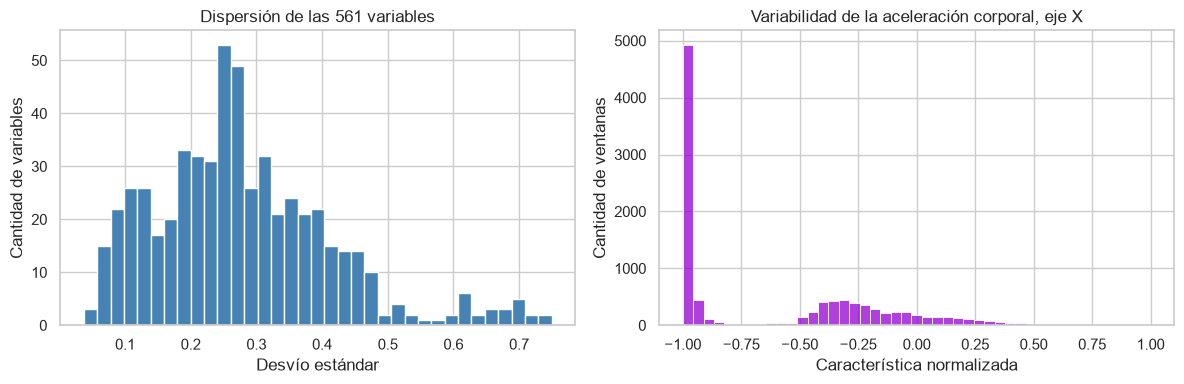

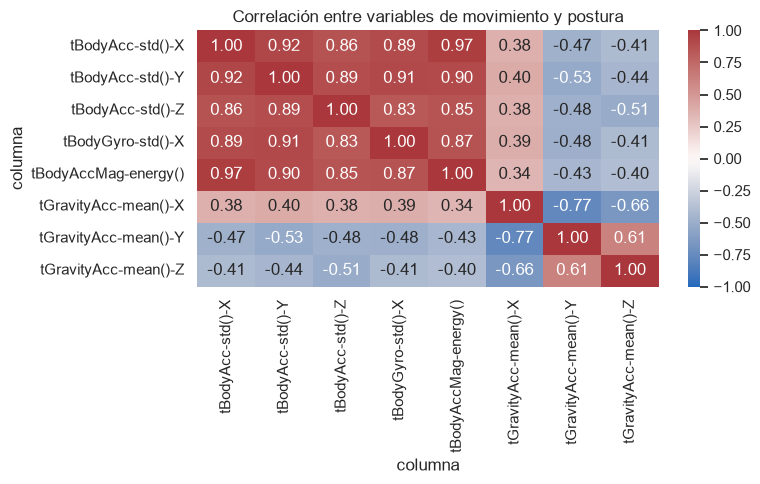

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X.std().hist(bins=35, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set(title="Dispersión de las 561 variables", xlabel="Desvío estándar",
            ylabel="Cantidad de variables")
sns.histplot(X[columna_por_nombre["tBodyAcc-std()-X"]], bins=45, ax=axes[1],
             color="darkviolet")
axes[1].set(title="Variabilidad de la aceleración corporal, eje X",
            xlabel="Característica normalizada", ylabel="Cantidad de ventanas")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(X[cols_perfil].rename(columns=dict(zip(cols_perfil, variables_perfil)))
            .corr(), cmap="vlag", vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlación entre variables de movimiento y postura")
plt.tight_layout()
plt.show()

No aparecen faltantes, infinitos, filas completas repetidas ni variables constantes. Hay 84 nombres de características repetidos, que quedan diferenciados mediante su número original.

Los desvíos estándar de las variables son distintos a pesar del rango común entre -1 y 1. La distribución de la variabilidad de la aceleración en X concentra muchas ventanas cerca de -1 y tiene otra región más dispersa. Esto sugiere perfiles de movimiento diferentes, aunque todavía no asigno actividades a esas regiones.

Las variables de variabilidad corporal están fuertemente correlacionadas. Por ejemplo, los desvíos de la aceleración en X e Y tienen una correlación de aproximadamente 0,92. Esa redundancia respalda el uso de PCA.

### 2.2. Preparación de las variables

Armo un pipeline con imputación por mediana y estandarización. La imputación queda definida para mantener el procedimiento completo, aunque no hay faltantes en los archivos utilizados. StandardScaler centra cada variable y la divide por su desvío estándar para que las variables con más dispersión no dominen por su escala.

Conservo todas las características. La estandarización también puede dar peso a variables poco variables o ruidosas, así que las conclusiones dependen de esta elección. No elimino ventanas extremas de forma automática: pueden corresponder a movimientos válidos.

El pipeline recibe únicamente X. No incluye actividad, sujeto ni partición.

In [7]:
preprocesador = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_scaled = preprocesador.fit_transform(X)
print("Forma de la matriz estandarizada:", X_scaled.shape)
print("Máximo valor absoluto de las medias:", np.abs(X_scaled.mean(axis=0)).max())
print("Desvíos estándar mínimo y máximo:",
      X_scaled.std(axis=0).min(), X_scaled.std(axis=0).max())

Forma de la matriz estandarizada: (10299, 561)
Máximo valor absoluto de las medias: 2.5975273328835587e-15
Desvíos estándar mínimo y máximo: 0.9999999999999998 1.0000000000000002


## 3. Reducción de dimensionalidad y clustering

### 3.1. PCA: representación compacta (punto a)

Elijo PCA porque las variables son numéricas y muchas describen aspectos relacionados de las mismas señales. PCA permite resumir esa redundancia mediante combinaciones lineales y medir la varianza retenida.

Fijo de antemano un umbral de 95% de varianza explicada. No interpreto ese porcentaje como 95% de toda la información útil, PCA conserva varianza y puede perder diferencias pequeñas relevantes para distinguir actividades. Mantengo las componentes sin blanqueamiento, de manera que las de mayor varianza sigan pesando más en las distancias.

Los métodos de clustering usarán todas las componentes retenidas. Las primeras dos se usan solamente para visualizar.

Variables originales: 561
Componentes retenidas: 104
Varianza explicada: 95.05%
Varianza de las primeras dos componentes: 56.98%
Reducción de dimensiones: 81.46%


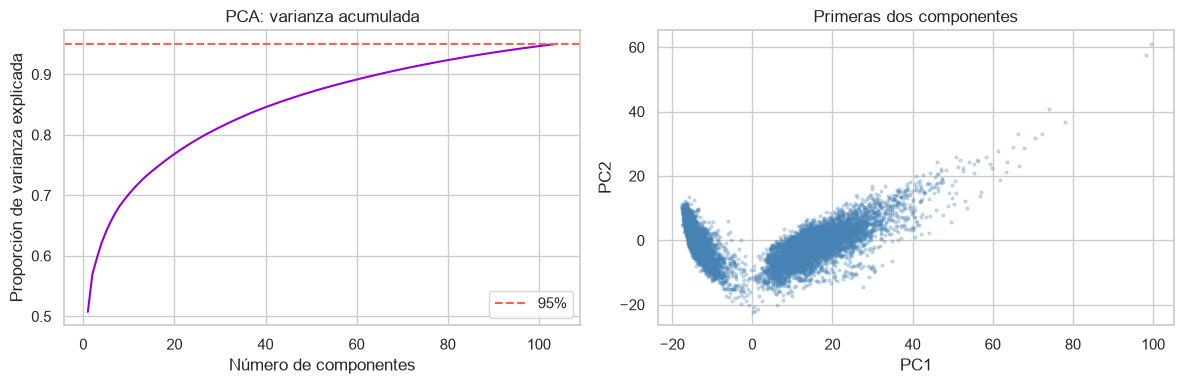

In [8]:
pca = PCA(n_components=0.95, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(f"Variables originales: {X.shape[1]}")
print(f"Componentes retenidas: {pca.n_components_}")
print(f"Varianza explicada: {varianza_acumulada[-1]:.2%}")
print(f"Varianza de las primeras dos componentes: {varianza_acumulada[1]:.2%}")
print(f"Reducción de dimensiones: {1 - X_pca.shape[1] / X.shape[1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
componentes = np.arange(1, pca.n_components_ + 1)
axes[0].plot(componentes, varianza_acumulada, color="darkviolet")
axes[0].axhline(0.95, color="tomato", ls="--", label="95%")
axes[0].set(title="PCA: varianza acumulada", xlabel="Número de componentes",
            ylabel="Proporción de varianza explicada")
axes[0].legend()
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], s=4, alpha=0.25, color="steelblue")
axes[1].set(title="Primeras dos componentes", xlabel="PC1", ylabel="PC2")
plt.tight_layout()
plt.show()

PCA reduce las 561 variables a 104 componentes, una reducción del 81,46%, y retiene el 95,05% de la varianza. La primera parte de la curva crece rápido y luego incorpora varianza más lentamente, consistente con la redundancia observada.

Las primeras dos componentes explican el 56,98%. En el gráfico aparecen regiones con forma y dispersión diferentes, además de algunas ventanas alejadas. La figura orienta la exploración, pero deja fuera parte de la estructura: las métricas y los modelos se calculan en las 104 componentes, no sobre ese dibujo.

### 3.2. Comparación de K-means y GMM (puntos b y c)

K-means agrupa por cercanía a centroides y tiende a favorecer grupos compactos. GMM modela una mezcla de distribuciones gaussianas, con covarianza completa puede representar grupos elipsoidales y asigna probabilidades de pertenencia.

Pruebo entre 2 y 8 grupos para cada método, sin imponer la cantidad de actividades conocidas. Para K-means uso 10 inicializaciones. Para GMM uso 2 inicializaciones, covarianza completa, regularización de 0,000001 y un máximo de 300 iteraciones.

Comparo las soluciones en el espacio PCA mediante:

- Silueta: valores más altos indican mayor cohesión y separación. Es el criterio principal de selección.
- Calinski-Harabasz: valores más altos indican mayor separación relativa a la dispersión interna.
- Davies-Bouldin: valores más bajos indican menor semejanza entre grupos.

Calculo la silueta sobre las mismas 2.000 ventanas elegidas al azar, sin estratificar por actividad, para reducir el costo. Las otras dos métricas usan todas las ventanas. La selección es exploratoria: evalúo la estructura del mismo conjunto sobre el que ajusto los modelos, no un desempeño fuera de muestra.

In [9]:
rng = np.random.default_rng(SEED)
idx_silueta = np.sort(rng.choice(len(X_pca), size=2000, replace=False))
modelos, etiquetas = {}, {}
resultados = []

for metodo in ["K-means", "GMM"]:
    for k in range(2, 9):
        if metodo == "K-means":
            modelo = KMeans(n_clusters=k, n_init=10, max_iter=300,
                            random_state=SEED)
        else:
            modelo = GaussianMixture(n_components=k, covariance_type="full",
                                     n_init=2, max_iter=300, reg_covar=1e-6,
                                     random_state=SEED)
        labels = modelo.fit_predict(X_pca)
        modelos[(metodo, k)] = modelo
        etiquetas[(metodo, k)] = labels
        score = silhouette_score(X_pca[idx_silueta], labels[idx_silueta])
        resultados.append({
            "Método": metodo, "k": k, "Silueta": score,
            "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels),
            "Davies-Bouldin": davies_bouldin_score(X_pca, labels),
            "Convergió": modelo.converged_ if metodo == "GMM" else True,
        })
        print(f"{metodo}, k={k}: silueta={score:.3f}")

resultados = pd.DataFrame(resultados)
display(resultados.round(3))

K-means, k=2: silueta=0.414
K-means, k=3: silueta=0.333
K-means, k=4: silueta=0.160
K-means, k=5: silueta=0.136
K-means, k=6: silueta=0.123
K-means, k=7: silueta=0.090
K-means, k=8: silueta=0.082
GMM, k=2: silueta=0.381
GMM, k=3: silueta=0.230
GMM, k=4: silueta=0.170
GMM, k=5: silueta=0.145
GMM, k=6: silueta=0.109
GMM, k=7: silueta=0.059
GMM, k=8: silueta=0.095


,Método,k,Silueta,Calinski-Harabasz,Davies-Bouldin,Convergió
0,K-means,2,0.414,8635.778,1.019,True
1,K-means,3,0.333,5580.549,1.689,True
2,K-means,4,0.160,4119.476,2.210,True
3,K-means,5,0.136,3391.779,2.271,True
4,K-means,6,0.123,2874.634,2.239,True
5,K-means,7,0.090,2500.490,2.486,True
6,K-means,8,0.082,2232.532,2.428,True
7,GMM,2,0.381,7291.553,1.079,True
8,GMM,3,0.230,4671.462,2.151,True
9,GMM,4,0.170,3889.809,2.406,True


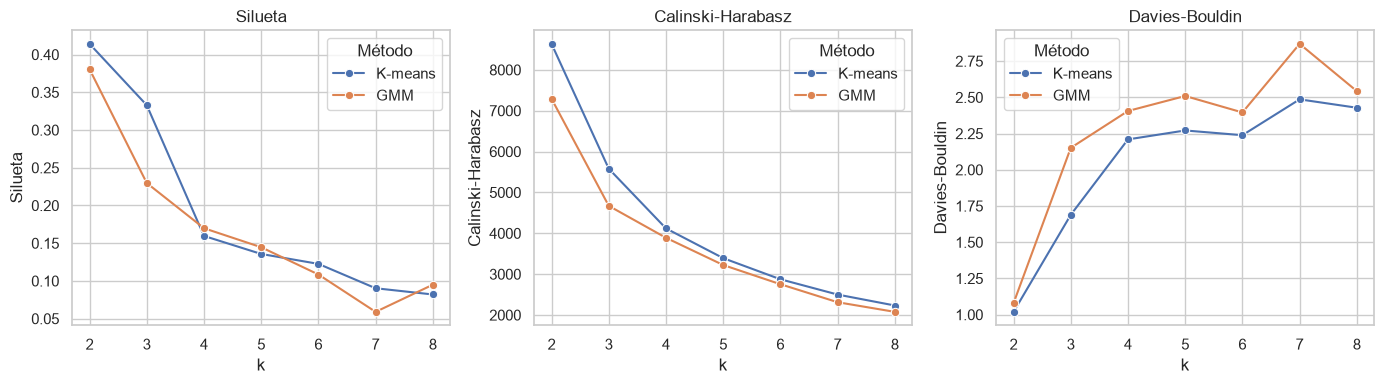

,Método,k,Silueta,Calinski-Harabasz,Davies-Bouldin,Convergió
0,K-means,2,0.414,8635.778,1.019,True
1,GMM,2,0.381,7291.553,1.079,True


Solución elegida: K-means, k=2
Acuerdo entre las mejores soluciones (ARI): 0.830


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metrica in zip(axes, ["Silueta", "Calinski-Harabasz", "Davies-Bouldin"]):
    sns.lineplot(data=resultados, x="k", y=metrica, hue="Método",
                 marker="o", ax=ax)
    ax.set_title(metrica)
    ax.set_xticks(range(2, 9))
plt.tight_layout()
plt.show()

# Selección sin utilizar etiquetas de actividad.
mejores = resultados.loc[resultados.groupby("Método")["Silueta"].idxmax()].copy()
mejores = mejores.sort_values("Silueta", ascending=False).reset_index(drop=True)
display(mejores.round(3))
metodo_elegido = mejores.loc[0, "Método"]
k_elegido = int(mejores.loc[0, "k"])
modelo_elegido = modelos[(metodo_elegido, k_elegido)]
clusters = etiquetas[(metodo_elegido, k_elegido)]

mejor_kmeans = int(mejores.loc[mejores["Método"] == "K-means", "k"].iloc[0])
mejor_gmm = int(mejores.loc[mejores["Método"] == "GMM", "k"].iloc[0])
ari_metodos = adjusted_rand_score(etiquetas[("K-means", mejor_kmeans)],
                                 etiquetas[("GMM", mejor_gmm)])
print(f"Solución elegida: {metodo_elegido}, k={k_elegido}")
print(f"Acuerdo entre las mejores soluciones (ARI): {ari_metodos:.3f}")

En ambos métodos, k=2 obtiene la mayor silueta entre las alternativas evaluadas. Elijo K-means con dos clusters porque también presenta el mayor Calinski-Harabasz y el menor Davies-Bouldin:

| Método | Silueta | Calinski-Harabasz | Davies-Bouldin |
|---|---:|---:|---:|
| K-means, k=2 | 0,414 | 8.635,778 | 1,019 |
| GMM, k=2 | 0,381 | 7.291,553 | 1,079 |

Todos los GMM convergieron. Al aumentar la cantidad de grupos, la silueta cae y no aparece una mejora que justifique una partición más detallada con este criterio.

Las mejores soluciones comparten buena parte de sus asignaciones, con ARI de 0,830, pero no son iguales. En la proyección PCA, GMM incorpora al grupo más disperso varias ventanas de la zona intermedia que K-means mantiene en el otro grupo. Es coherente con que GMM admite distintas covarianzas y asigna por probabilidad, mientras K-means asigna por cercanía al centro.

La silueta elegida deja un 0,40% de valores negativos en la muestra. La separación es consistente con los gráficos, aunque no es perfecta. Además, estas métricas euclídeas favorecen grupos compactos, por lo que la elección responde al objetivo de encontrar una partición clara en esta representación, no demuestra que K-means sea superior para cualquier uso.

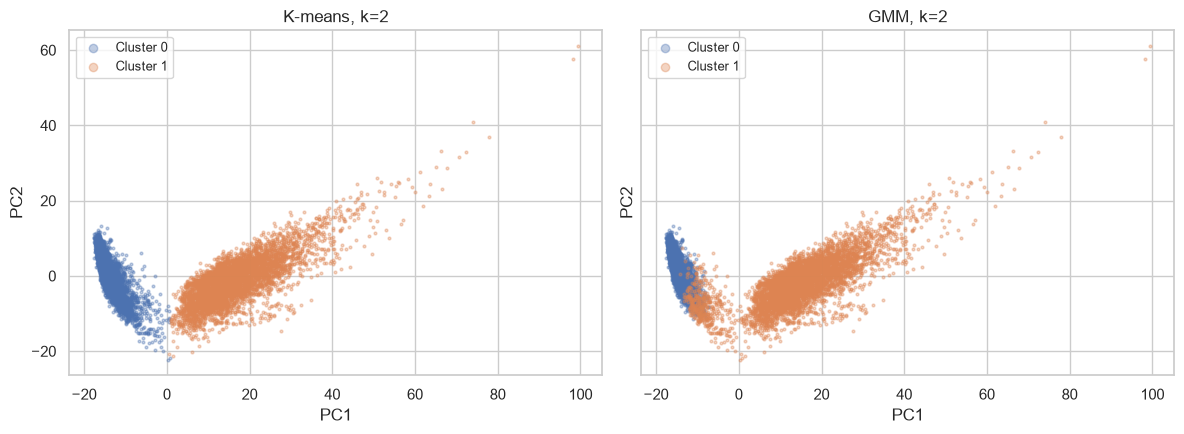

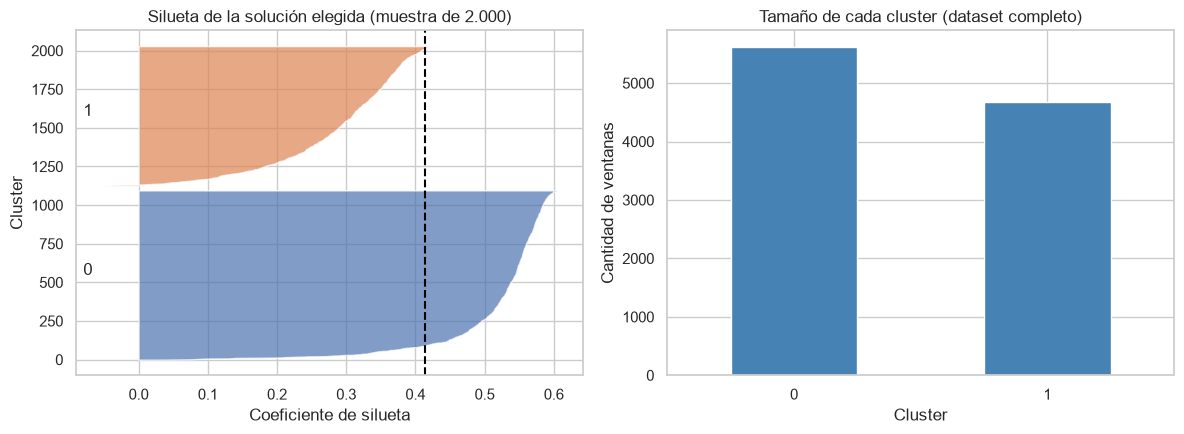

Porcentaje de siluetas negativas en la muestra: 0.40%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, metodo, k in zip(axes, ["K-means", "GMM"], [mejor_kmeans, mejor_gmm]):
    labels = etiquetas[(metodo, k)]
    for grupo in np.unique(labels):
        mask = labels == grupo
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.35,
                   label=f"Cluster {grupo}")
    ax.set(title=f"{metodo}, k={k}", xlabel="PC1", ylabel="PC2")
    ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

labels_muestra = clusters[idx_silueta]
valores_silueta = silhouette_samples(X_pca[idx_silueta], labels_muestra)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
y_lower = 0
for grupo in np.unique(clusters):
    valores = np.sort(valores_silueta[labels_muestra == grupo])
    y_upper = y_lower + len(valores)
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, valores, alpha=0.7)
    axes[0].text(-0.08, (y_lower + y_upper) / 2, str(grupo))
    y_lower = y_upper + 30
axes[0].axvline(valores_silueta.mean(), ls="--", color="black")
axes[0].set(title="Silueta de la solución elegida (muestra de 2.000)",
            xlabel="Coeficiente de silueta", ylabel="Cluster")
pd.Series(clusters).value_counts().sort_index().plot.bar(ax=axes[1], color="steelblue")
axes[1].set(title="Tamaño de cada cluster (dataset completo)",
            xlabel="Cluster", ylabel="Cantidad de ventanas")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print(f"Porcentaje de siluetas negativas en la muestra: {(valores_silueta < 0).mean():.2%}")

### 3.3. Estabilidad de la solución

Repito la solución elegida con otras tres semillas y comparo las asignaciones mediante ARI, que no depende de los números asignados a los clusters. Esto evalúa sensibilidad a la inicialización, no reemplaza una prueba con sujetos nuevos ni una evaluación por remuestreo.

In [12]:
estabilidad = []
for semilla in [0, 7, 21]:
    if metodo_elegido == "K-means":
        modelo = KMeans(n_clusters=k_elegido, n_init=10, random_state=semilla)
    else:
        modelo = GaussianMixture(n_components=k_elegido, covariance_type="full",
                                 n_init=2, max_iter=300, reg_covar=1e-6,
                                 random_state=semilla)
    labels = modelo.fit_predict(X_pca)
    estabilidad.append({"Semilla": semilla,
                        "ARI con la solución elegida": adjusted_rand_score(clusters, labels)})
estabilidad = pd.DataFrame(estabilidad)
display(estabilidad.round(4))

,Semilla,ARI con la solución elegida
0,0,1.0
1,7,1.0
2,21,1.0


Las semillas 0, 7 y 21 producen ARI de 1,000 respecto de la solución elegida, las asignaciones coinciden, aunque los números de cluster pueden intercambiarse. En esta prueba, la división no depende de la inicialización. Esto no garantiza que se mantenga al cambiar las personas, el teléfono o las condiciones de medición.

### 3.4. Interpretación con las actividades conocidas (punto d)

Con la elección del modelo ya cerrada, cargo la actividad de cada ventana. Reviso los tamaños de los grupos y su composición de dos formas: porcentajes dentro de cada cluster y porcentajes de cada actividad que caen en cada cluster.

Un cluster puede contener varias actividades. Por eso no interpreto su número como una predicción de clase. ARI y AMI con las actividades sirven para describir la correspondencia posterior y no intervienen en la elección del modelo.

,Ventanas,% del dataset,Actividad más frecuente,% de la actividad más frecuente,Sujetos
cluster,,,,,
0,5620,54.57,Acostado,34.38,30
1,4679,45.43,Caminar,36.80,30


actividad,Caminar,Subir escaleras,Bajar escaleras,Sentado,De pie,Acostado
cluster,,,,,,
0,0,8,0,1774,1906,1932
1,1722,1536,1406,3,0,12


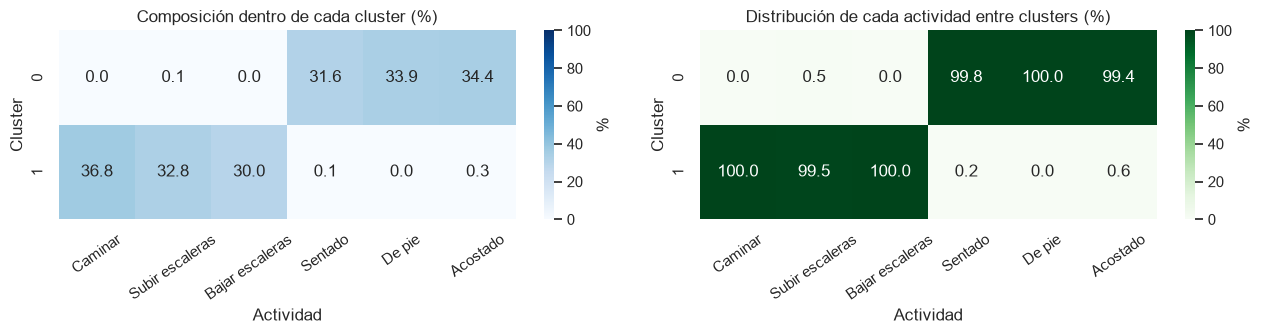

ARI con las seis actividades: 0.330
AMI con las seis actividades: 0.545


In [13]:
nombres_actividad = {
    1: "Caminar", 2: "Subir escaleras", 3: "Bajar escaleras",
    4: "Sentado", 5: "De pie", 6: "Acostado",
}
y = np.concatenate([
    np.loadtxt(ruta / p / f"y_{p}.txt", dtype=int) for p in ["train", "test"]
])
analisis = meta.copy()
analisis["actividad"] = pd.Series(y).map(nombres_actividad)
analisis["cluster"] = clusters
orden_actividades = list(nombres_actividad.values())
conteos = pd.crosstab(analisis.cluster, analisis.actividad).reindex(columns=orden_actividades)
por_cluster = conteos.div(conteos.sum(axis=1), axis=0) * 100
por_actividad = conteos.div(conteos.sum(axis=0), axis=1) * 100
resumen_clusters = pd.DataFrame({
    "Ventanas": conteos.sum(axis=1),
    "% del dataset": conteos.sum(axis=1) / len(X) * 100,
    "Actividad más frecuente": conteos.idxmax(axis=1),
    "% de la actividad más frecuente": por_cluster.max(axis=1),
    "Sujetos": analisis.groupby("cluster").sujeto.nunique(),
})
display(resumen_clusters.round(2))
display(conteos)

fig, axes = plt.subplots(1, 2, figsize=(13, max(3.5, k_elegido * 0.6)))
sns.heatmap(por_cluster, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
            ax=axes[0], cbar_kws={"label": "%"})
axes[0].set_title("Composición dentro de cada cluster (%)")
sns.heatmap(por_actividad, annot=True, fmt=".1f", cmap="Greens", vmin=0, vmax=100,
            ax=axes[1], cbar_kws={"label": "%"})
axes[1].set_title("Distribución de cada actividad entre clusters (%)")
for ax in axes:
    ax.set_xlabel("Actividad")
    ax.set_ylabel("Cluster")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

ari_actividad = adjusted_rand_score(y, clusters)
ami_actividad = adjusted_mutual_info_score(y, clusters)
print(f"ARI con las seis actividades: {ari_actividad:.3f}")
print(f"AMI con las seis actividades: {ami_actividad:.3f}")

El cluster 0 tiene 5.620 ventanas, el 54,57% del dataset. Agrupa principalmente las tres posturas estáticas: acostado (34,4%), de pie (33,9%) y sentado (31,6%). Solo contiene 8 ventanas de subir escaleras.

El cluster 1 tiene 4.679 ventanas, el 45,43%. Su composición principal es caminar (36,8%), subir escaleras (32,8%) y bajar escaleras (30,0%). También contiene 3 ventanas de sentado y 12 de acostado.

El 100% de caminar y bajar escaleras cae en el cluster 1, y el 99,5% de subir escaleras también. Para las posturas, el cluster 0 reúne el 100% de de pie, el 99,8% de sentado y el 99,4% de acostado. Ambos grupos incluyen ventanas de los 30 sujetos, así que la partición no separa simplemente a unas personas de otras.

Esto respalda la hipótesis inicial sobre movimiento frente a postura estática. Hay una correspondencia clara con ese nivel general del dominio, pero no una correspondencia uno a uno con las seis actividades. Caminar y utilizar escaleras quedan mezclados en el mismo grupo, sentado, de pie y acostado también comparten grupo.

Los valores ARI=0,330 y AMI=0,545 frente a las seis etiquetas reflejan esa correspondencia parcial. No son una exactitud de clasificación y no se utilizaron para seleccionar el modelo. El solapamiento entre actividades dentro de un cluster no demuestra que esas actividades sean indistinguibles en toda la representación.

### 3.5. Características que distinguen los grupos

Vuelvo a las variables originales para interpretar los clusters. Comparo medidas de variabilidad de la aceleración y del giroscopio, energía de la aceleración y medias de la gravedad en los tres ejes.

El mapa de calor muestra las medias en unidades estandarizadas. Los boxplots conservan la escala normalizada del archivo: no representan directamente aceleraciones en g ni energías en unidades físicas. Una media por encima de cero en el mapa significa un valor mayor que el promedio del dataset.

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyGyro-std()-X,tBodyAccMag-energy(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z
cluster,,,,,,,,
0,-0.991,-0.974,-0.977,-0.985,-1.000,0.893,0.064,0.162
1,-0.224,-0.030,-0.258,-0.459,-0.578,0.929,-0.225,-0.037


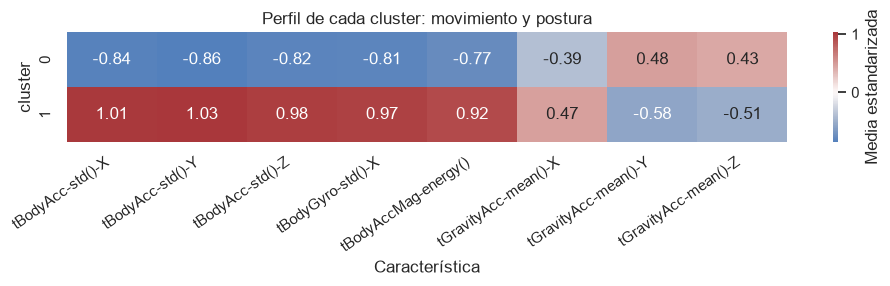

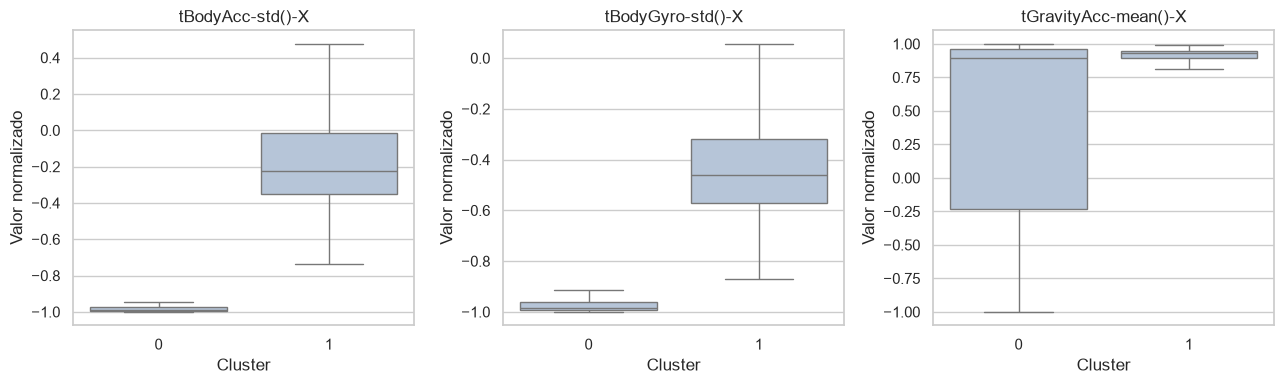

In [14]:
perfil_original = X[cols_perfil].copy()
perfil_original.columns = variables_perfil
perfil_original["cluster"] = clusters
medianas_perfil = perfil_original.groupby("cluster").median()
display(medianas_perfil.round(3))

perfil_z = pd.DataFrame(X_scaled, columns=X.columns)[cols_perfil].copy()
perfil_z.columns = variables_perfil
perfil_z["cluster"] = clusters
fig, ax = plt.subplots(figsize=(10, max(3, k_elegido * 0.6)))
sns.heatmap(perfil_z.groupby("cluster").mean(), annot=True, fmt=".2f",
            cmap="vlag", center=0, ax=ax, cbar_kws={"label": "Media estandarizada"})
ax.set_title("Perfil de cada cluster: movimiento y postura")
ax.set_xlabel("Característica")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, variable in zip(axes, ["tBodyAcc-std()-X", "tBodyGyro-std()-X",
                              "tGravityAcc-mean()-X"]):
    sns.boxplot(data=perfil_original, x="cluster", y=variable, ax=ax,
                color="lightsteelblue", showfliers=False)
    ax.set_xlabel("Cluster")
    ax.set_title(variable)
    ax.set_ylabel("Valor normalizado")
plt.tight_layout()
plt.show()

Las características de movimiento muestran la diferencia principal. En el cluster 0, las medianas de variabilidad de la aceleración corporal están cerca de -1, en X es -0,991, frente a -0,224 en el cluster 1. Para el giroscopio en X, las medianas son -0,985 y -0,459. La energía de la aceleración corporal también es mayor en el cluster 1.

En el mapa estandarizado, el cluster 0 queda por debajo del promedio en las medidas de movimiento y el cluster 1 por encima. Esto es coherente con las actividades estáticas y dinámicas observadas en la composición.

Las variables de gravedad ayudan a describir la postura, pero el cluster 0 combina varias orientaciones. El boxplot de la gravedad en X muestra una dispersión amplia dentro de ese grupo, mientras el grupo de movimiento tiene valores más concentrados. Por eso una mediana del cluster no alcanza para describir todas sus posturas.

Los clusters aportan una división general entre bajo y alto movimiento corporal. Puede servir como una primera segmentación para estudiar después las actividades dentro de cada régimen, pero esta solución por sí sola no identifica las seis clases.

### 3.6. Observaciones representativas

Para cada cluster selecciono las dos ventanas más cercanas a la media de sus puntos en el espacio PCA. Son ejemplos centrales de la solución, no prototipos garantizados de todas las actividades del grupo. Conservo el registro, sujeto, partición y número de fila original para poder ubicarlos en los archivos.

Después comparo sus señales originales de aceleración corporal y velocidad angular en el eje X. Estas señales sí están expresadas en g y rad/s, respectivamente.

In [15]:
registros_representativos = []
for grupo in np.unique(clusters):
    idx = np.flatnonzero(clusters == grupo)
    centro = X_pca[idx].mean(axis=0)
    distancias = np.linalg.norm(X_pca[idx] - centro, axis=1)
    orden = np.argsort(distancias)[:2]
    for posicion in orden:
        registro = int(idx[posicion])
        fila = analisis.loc[registro].to_dict()
        fila["registro"] = registro
        fila["distancia_al_centro"] = float(distancias[posicion])
        registros_representativos.append(fila)

representantes = pd.DataFrame(registros_representativos)
display(representantes[["cluster", "registro", "particion", "fila_original",
                        "sujeto", "actividad", "distancia_al_centro"]].round(3))
valores_representantes = X.loc[representantes.registro, cols_perfil].copy()
valores_representantes.columns = variables_perfil
valores_representantes.insert(0, "cluster", representantes.cluster.to_numpy())
display(valores_representantes.round(3))

,cluster,registro,particion,fila_original,sujeto,actividad,distancia_al_centro
0,0,6500,train,6501,28,Sentado,6.829
1,0,8305,test,954,10,Sentado,7.004
2,1,6577,train,6578,28,Caminar,10.231
3,1,651,train,652,3,Bajar escaleras,10.243


,cluster,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyGyro-std()-X,tBodyAccMag-energy(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z
registro,,,,,,,,,
6500,0,-0.991,-0.967,-0.967,-0.988,-1.000,0.907,-0.061,0.326
8305,0,-0.995,-0.983,-0.981,-0.994,-1.000,0.887,0.274,0.130
6577,1,-0.245,-0.106,-0.348,-0.509,-0.648,0.938,-0.228,-0.134
651,1,-0.136,-0.038,-0.330,-0.216,-0.565,0.931,-0.195,-0.094


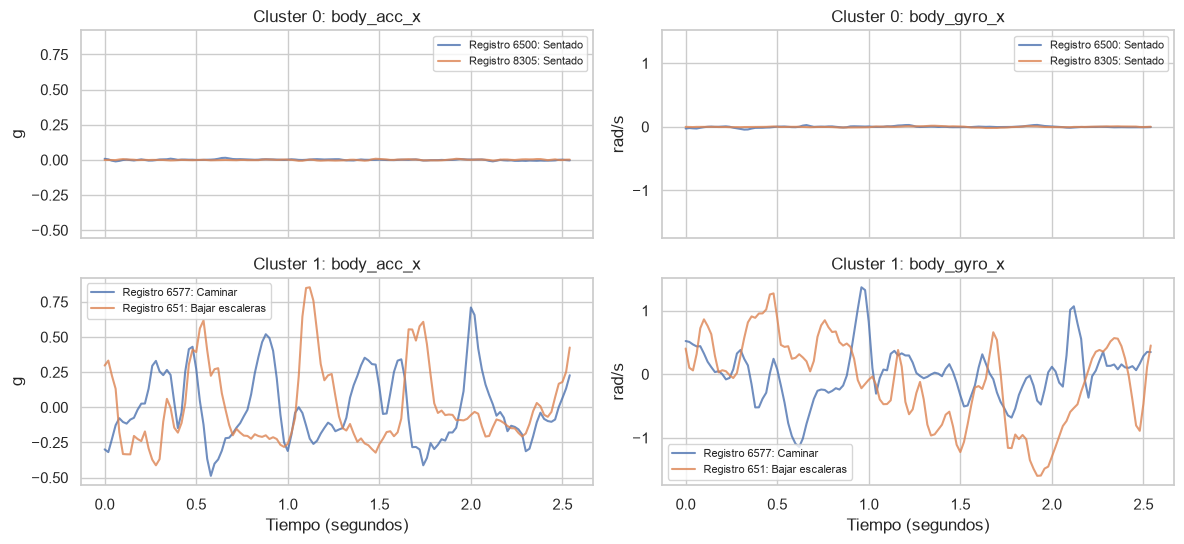

In [16]:
seniales = {}
for particion in representantes.particion.unique():
    for nombre in ["body_acc_x", "body_gyro_x"]:
        seniales[(particion, nombre)] = np.loadtxt(
            ruta / particion / "Inertial Signals" / f"{nombre}_{particion}.txt"
        )

tiempo = np.arange(128) / 50
fig, axes = plt.subplots(k_elegido, 2, figsize=(12, 2.8 * k_elegido),
                         squeeze=False, sharex=True, sharey="col")
for fila_ax, grupo in enumerate(np.unique(clusters)):
    ejemplos = representantes[representantes.cluster == grupo]
    for _, ejemplo in ejemplos.iterrows():
        fila_archivo = int(ejemplo.fila_original) - 1
        for col_ax, nombre, unidad in [(0, "body_acc_x", "g"),
                                        (1, "body_gyro_x", "rad/s")]:
            axes[fila_ax, col_ax].plot(
                tiempo, seniales[(ejemplo.particion, nombre)][fila_archivo],
                label=f"Registro {int(ejemplo.registro)}: {ejemplo.actividad}", alpha=0.8,
            )
            axes[fila_ax, col_ax].set_title(f"Cluster {grupo}: {nombre}")
            axes[fila_ax, col_ax].set_ylabel(unidad)
            axes[fila_ax, col_ax].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Tiempo (segundos)")
plt.tight_layout()
plt.show()

Los registros 6500 y 8305, del cluster 0, corresponden a personas sentadas. En ambos, la aceleración corporal y la velocidad angular permanecen muy cerca de cero. Los registros 6577 y 651, del cluster 1, corresponden a caminar y bajar escaleras, muestran oscilaciones y amplitudes mucho mayores.

Los ejemplos confirman la interpretación de baja y alta intensidad de movimiento. Que los dos representantes del cluster 0 sean de sentado, aunque acostado sea su actividad más frecuente, recuerda que el criterio de selección fue cercanía al centro y no frecuencia de clase. Para describir el grupo completo considero también su composición y la dispersión de las variables.

## 4. Visualización e interpretación con UMAP

Incluyo la sección opcional. Ajusto UMAP directamente sobre las 561 variables originales estandarizadas, sin pasarle la representación PCA ni las etiquetas de actividad. Uso dos dimensiones, 30 vecinos, distancia mínima de 0,1, métrica euclídea y semilla 42.

Los 30 vecinos permiten explorar relaciones locales sin enfocarse únicamente en pares de ventanas. La distancia mínima de 0,1 admite grupos relativamente compactos. Estos parámetros se fijan para visualizar la estructura, no para recuperar las seis actividades.

Muestro el mismo mapa sin etiquetas, coloreado por los clusters elegidos y coloreado por la actividad real. Los colores se agregan después del ajuste. También calculo la confiabilidad de vecindarios (trustworthiness) sobre 1.500 ventanas elegidas al azar, un valor cercano a 1 indica menos vecinos falsos introducidos por la proyección en esa muestra.

Dimensiones de la proyección UMAP: (10299, 2)


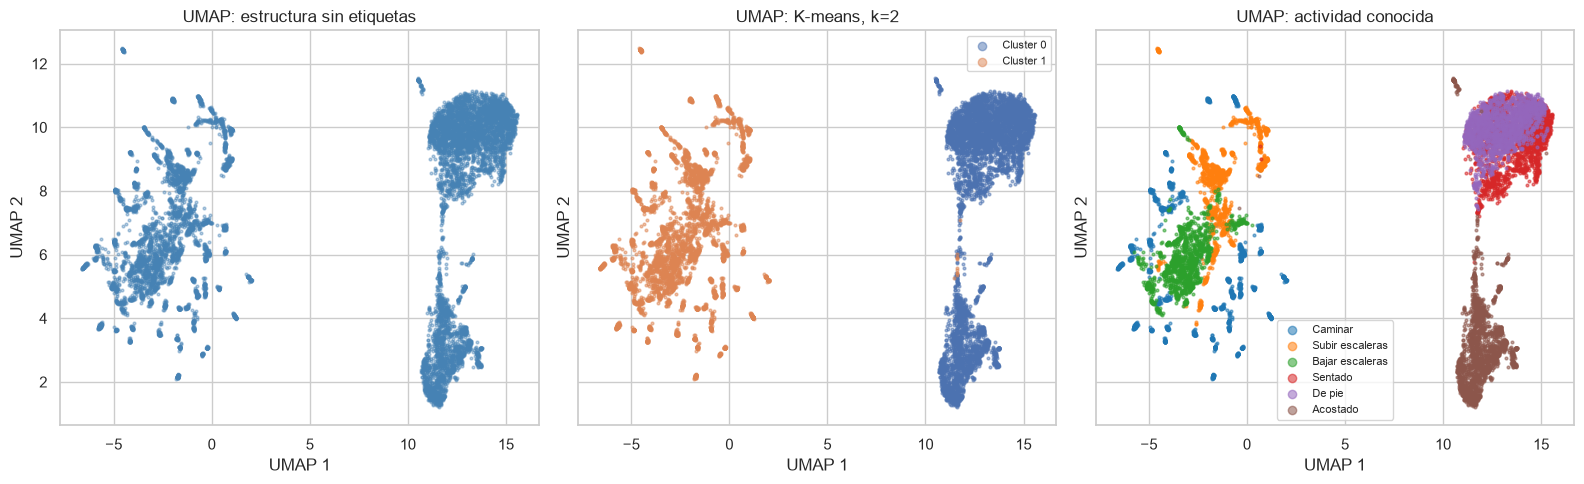

In [17]:
umap_model = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.1,
    metric="euclidean", n_epochs=300, n_jobs=1, random_state=SEED,
)
X_umap = umap_model.fit_transform(X_scaled)
print("Dimensiones de la proyección UMAP:", X_umap.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], s=4, alpha=0.4, color="steelblue")
axes[0].set_title("UMAP: estructura sin etiquetas")
for grupo in np.unique(clusters):
    mask = clusters == grupo
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], s=4, alpha=0.5,
                    label=f"Cluster {grupo}")
axes[1].set_title(f"UMAP: {metodo_elegido}, k={k_elegido}")
axes[1].legend(markerscale=3, fontsize=8)
colores_actividad = sns.color_palette("tab10", 6)
for actividad, color in zip(nombres_actividad, colores_actividad):
    mask = y == actividad
    axes[2].scatter(X_umap[mask, 0], X_umap[mask, 1], s=4, alpha=0.55,
                    color=color, label=nombres_actividad[actividad])
axes[2].set_title("UMAP: actividad conocida")
axes[2].legend(markerscale=3, fontsize=8)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.manifold import trustworthiness

idx_umap = np.sort(np.random.default_rng(SEED).choice(len(X), size=1500, replace=False))
confiabilidad_umap = trustworthiness(X_scaled[idx_umap], X_umap[idx_umap],
                                     n_neighbors=15)
print(f"Trustworthiness (15 vecinos, muestra de 1.500): {confiabilidad_umap:.3f}")

Trustworthiness (15 vecinos, muestra de 1.500): 0.937


UMAP muestra dos grandes regiones compatibles con la partición de K-means, a la izquierda se concentran las actividades con movimiento y a la derecha las posturas estáticas. Esa coincidencia aparece aunque UMAP se ajustó directamente sobre las 561 variables y no recibió los clusters.

Dentro de la región estática se observa más detalle, acostado ocupa principalmente la zona inferior derecha, mientras sentado y de pie se concentran arriba y presentan bastante solapamiento. La postura sí aporta una estructura adicional que la solución de dos clusters resume dentro de un único grupo.

Las actividades dinámicas forman regiones más fragmentadas. Subir escaleras aparece con mayor presencia en la parte superior izquierda, bajar escaleras se concentra en una zona central y caminar está más extendido, con zonas compartidas entre actividades. Hay pequeñas islas y puntos separados, el mapa permite identificarlos para una revisión posterior, pero no alcanza para marcarlos como errores o anomalías.

Las zonas superiores e inferiores de la región estática parecen más compactas, y las ventanas dinámicas se distribuyen en varias concentraciones. Estas diferencias son visuales: UMAP puede modificar las distancias y densidades y la ubicación absoluta de los grupos depende de sus parámetros. No interpreto sus ejes como magnitudes físicas ni las distancias entre islas como una medida exacta de diferencia entre actividades.

La confiabilidad de vecindarios es 0,937 para 15 vecinos en la muestra de 1.500 ventanas. Indica una buena conservación local con ese criterio, sin garantizar la preservación de las distancias globales ni que todas las separaciones visuales sean clusters reales. El aporte principal del mapa es mostrar diferencias de postura y zonas de solapamiento que no se aprecian tan claramente en las primeras dos componentes de PCA.

## 5. Conclusiones

El dataset no presenta faltantes, infinitos ni filas completas repetidas en las características utilizadas. Después de estandarizar las 561 variables, PCA obtiene una representación de 104 componentes que conserva el 95,05% de la varianza.

La comparación de K-means y GMM entre 2 y 8 grupos favorece a K-means con dos clusters, silueta de 0,414, Calinski-Harabasz de 8.635,778 y Davies-Bouldin de 1,019. Las asignaciones se mantienen al repetir el ajuste con otras tres semillas.

La interpretación posterior respalda la hipótesis de una separación dominante entre posturas estáticas y actividades con movimiento. Las diferencias en variabilidad y energía de las señales, junto con las ventanas representativas, dan una explicación coherente con el dominio. Sin embargo, los dos grupos reúnen varias actividades y no reemplazan un clasificador de las seis clases.

UMAP permite observar una estructura más detallada, acostado se separa de buena parte de sentado y de pie, mientras estas últimas actividades muestran solapamiento. Dentro de las actividades dinámicas también aparecen concentraciones y zonas compartidas. La hipótesis sobre el efecto de la postura se aprecia mejor en ese mapa que en la partición de dos grupos.

El alcance es exploratorio. Las ventanas se solapan, cada persona aporta múltiples registros y se utilizaron las dos particiones originales para describir el conjunto completo. Los resultados dependen del escalado, del umbral de PCA, de las métricas elegidas y de los parámetros de UMAP. Para evaluar utilidad sobre personas nuevas haría una separación por sujeto y ajustaría el preprocesamiento solo en entrenamiento.

Como continuidad del análisis, estudiaría por separado la estructura dentro de los grupos estático y dinámico. Eso permitiría explorar la separación de posturas y de formas de desplazamiento sin forzar desde el inicio que el clustering reproduzca las seis etiquetas.